# CSE 445 Part B — Notebook 1a: SimCLR Pretraining on the KIIT-MiTA SSL Pool

| | |
|---|---|
| **Group Number** | `02` |
| **Instructor** | Dr. Mohammad Rifat Ahmmad Rashid, Associate Professor, Dept. of CSE, EWU |

| Name | ID |
|---|---|
| MD SHAFIN AHAMED SIAM | 2023-1-60-007 |
| ALBIN ISRAT SIDDIQUE | 2023-1-60-212 |
| Md. Ariful Islam Opi | 2023-1-60-141 |
| Nasrullah Kaisher Sijan | 2023-1-60-204 |

| Property | Value |
|---|---|
| **Dataset** | KIIT-MiTA (Military Target Detection) |
| **Source** | https://data.mendeley.com/datasets/drjmrf5kk5/1 |
| **Model** | SimCLR Pretrain |

- Pretrains a SimCLR backbone on YOLOv26n using `ssldet`, on the unlabelled SSL pool (labels discarded).
- Plots the SSL loss curve, runs t-SNE + nearest-neighbour diagnostics.
- Runs a short temperature-ablation exercise ($\tau=0.10$ vs. the main run's $\tau=0.20$).

## 1. Install `ssldet` and imports

In [1]:
%pip install -q --upgrade "git+https://github.com/rifat963/ssl-detection-lab.git@main" scikit-learn seaborn

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 65.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 66.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sklearn-compat 0.1.5 requires scikit-learn<1.9,>=1.2, but you have scikit-learn 1.9.0 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import random
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from packaging.version import Version
from PIL import Image
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
from tqdm.auto import tqdm
from ultralytics import YOLO

import ssldet
from ssldet import PretrainConfig, launch_distributed_pretrain
from ssldet.backbones import YOLOBackboneEncoder
from ssldet.data import IMAGENET_MEAN, IMAGENET_STD, UnlabeledImageDataset, build_transform

random.seed(0); np.random.seed(0); torch.manual_seed(0); torch.cuda.manual_seed_all(0)
torch.set_float32_matmul_precision("high")
sns.set_theme(style="whitegrid", context="notebook")

REQUIRED_SSLDET_VERSION = "0.8.1"
assert Version(ssldet.__version__) >= Version(REQUIRED_SSLDET_VERSION), (
    f"ssldet {ssldet.__version__} found, need >= {REQUIRED_SSLDET_VERSION}. "
    "Restart the kernel/session and rerun the install cell from the top, then re-run this cell."
)
print("ssl-detection-lab version:", ssldet.__version__)
assert torch.cuda.is_available(), "Select a GPU accelerator before continuing."

GPU_COUNT = torch.cuda.device_count()
DEVICE = torch.device("cuda:0")
print("GPUs:", GPU_COUNT)

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
ssl-detection-lab version: 0.9.0
GPUs: 2


## 2. Attach the Part B data-prep output (partition + SSL pool, already built)

In [3]:
import pathlib, json, yaml

_manifest_candidates = list(pathlib.Path("/kaggle/input").rglob("partition_manifest.json"))
if not _manifest_candidates:
    raise FileNotFoundError(
        "No partition_manifest.json found under /kaggle/input. "
        "Attach group02-partB-00-data-prep's output as an input to this notebook."
    )
PARTITION_MANIFEST_PATH = _manifest_candidates[0]
partition_manifest = json.loads(PARTITION_MANIFEST_PATH.read_text())
BASE_DIR = PARTITION_MANIFEST_PATH.parent

SEED = partition_manifest["seed"]
CLASS_NAMES = partition_manifest["class_names"]
NUM_CLASSES = len(CLASS_NAMES)
TARGET_RATIO = partition_manifest["target_ratio_copy_paste"]

RESPLIT_ROOT = BASE_DIR / "dataset-resplit"
SSL_POOL_TRAIN_DIR = RESPLIT_ROOT / "train" / "images"
SSL_POOL_VAL_DIR = RESPLIT_ROOT / "val" / "images"
SSL_POOL_TEST_DIR = RESPLIT_ROOT / "test" / "images"

for d in [SSL_POOL_TRAIN_DIR, SSL_POOL_VAL_DIR, SSL_POOL_TEST_DIR]:
    if not d.exists():
        raise FileNotFoundError(f"Expected directory missing: {d}")

stems_train = partition_manifest["stems_ssl_pool_raw"]
stems_val = partition_manifest["stems_val"]
stems_test = partition_manifest["stems_test"]

print("SSL pool (train) dir:", SSL_POOL_TRAIN_DIR, "| raw stems:", len(stems_train))
print("Val dir             :", SSL_POOL_VAL_DIR, "| stems:", len(stems_val))
print("Test dir            :", SSL_POOL_TEST_DIR, "| stems:", len(stems_test))
print("Classes:", CLASS_NAMES)

SSL pool (train) dir: /kaggle/input/notebooks/arifulislamopi/group02-dataset-eda/dataset-resplit/train/images | raw stems: 1339
Val dir             : /kaggle/input/notebooks/arifulislamopi/group02-dataset-eda/dataset-resplit/val/images | stems: 164
Test dir            : /kaggle/input/notebooks/arifulislamopi/group02-dataset-eda/dataset-resplit/test/images | stems: 178
Classes: ['Artilary', 'Missile', 'Radar', 'M. Rocket Launcher', 'Soldier', 'Tank', 'Vehicle']


## 3. Inspect the dataset

Total image counts per split (raw stems vs. what actually sits on disk the train folder additionally
contains copy-paste synthetic images), a per-class instance-count table across all three splits, and a
sample grid of raw training images.


In [4]:
IMAGE_SUFFIXES = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
def image_files(directory):
    return sorted(p for p in Path(directory).rglob("*") if p.is_file() and p.suffix.lower() in IMAGE_SUFFIXES)

train_images = image_files(SSL_POOL_TRAIN_DIR)
val_images = image_files(SSL_POOL_VAL_DIR)
test_images = image_files(SSL_POOL_TEST_DIR)

pd.Series({
    "train — raw stems (pre copy-paste)": len(stems_train),
    "train — on disk (raw + copy-paste)": len(train_images),
    "train — copy-paste synthetic added": len(train_images) - len(stems_train),
    "val — on disk (always raw, never augmented)": len(val_images),
    "test — on disk (always raw, never augmented)": len(test_images),
    "TOTAL images on disk (train + val + test)": len(train_images) + len(val_images) + len(test_images),
})

train — raw stems (pre copy-paste)              1339
train — on disk (raw + copy-paste)              2377
train — copy-paste synthetic added              1038
val — on disk (always raw, never augmented)      164
test — on disk (always raw, never augmented)     178
TOTAL images on disk (train + val + test)       2719
dtype: int64

In [5]:
# Per-class instance counts (reads YOLO label .txt files directly — these still exist on disk for
# every split, even though SSL pretraining itself never reads them for the train/SSL-pool split)
def count_class_instances(labels_dir):
    counts = Counter()
    for lbl_path in Path(labels_dir).glob("*.txt"):
        with open(lbl_path) as f:
            for line in f:
                parts = line.strip().split()
                if parts:
                    counts[int(float(parts[0]))] += 1
    return counts

train_label_counts = count_class_instances(RESPLIT_ROOT / "train" / "labels")
val_label_counts = count_class_instances(RESPLIT_ROOT / "val" / "labels")
test_label_counts = count_class_instances(RESPLIT_ROOT / "test" / "labels")

class_table = pd.DataFrame({
    "train (raw+copy-paste)": [train_label_counts.get(i, 0) for i in range(NUM_CLASSES)],
    "val": [val_label_counts.get(i, 0) for i in range(NUM_CLASSES)],
    "test": [test_label_counts.get(i, 0) for i in range(NUM_CLASSES)],
}, index=CLASS_NAMES)
class_table["total"] = class_table.sum(axis=1)
class_table.index.name = "class name"
class_table

,train (raw+copy-paste),val,test,total
class name,,,,
Artilary,610,29,28,667
Missile,764,40,45,849
Radar,772,33,29,834
M. Rocket Launcher,705,33,36,774
Soldier,937,113,92,1142
Tank,824,81,94,999
Vehicle,1033,93,159,1285


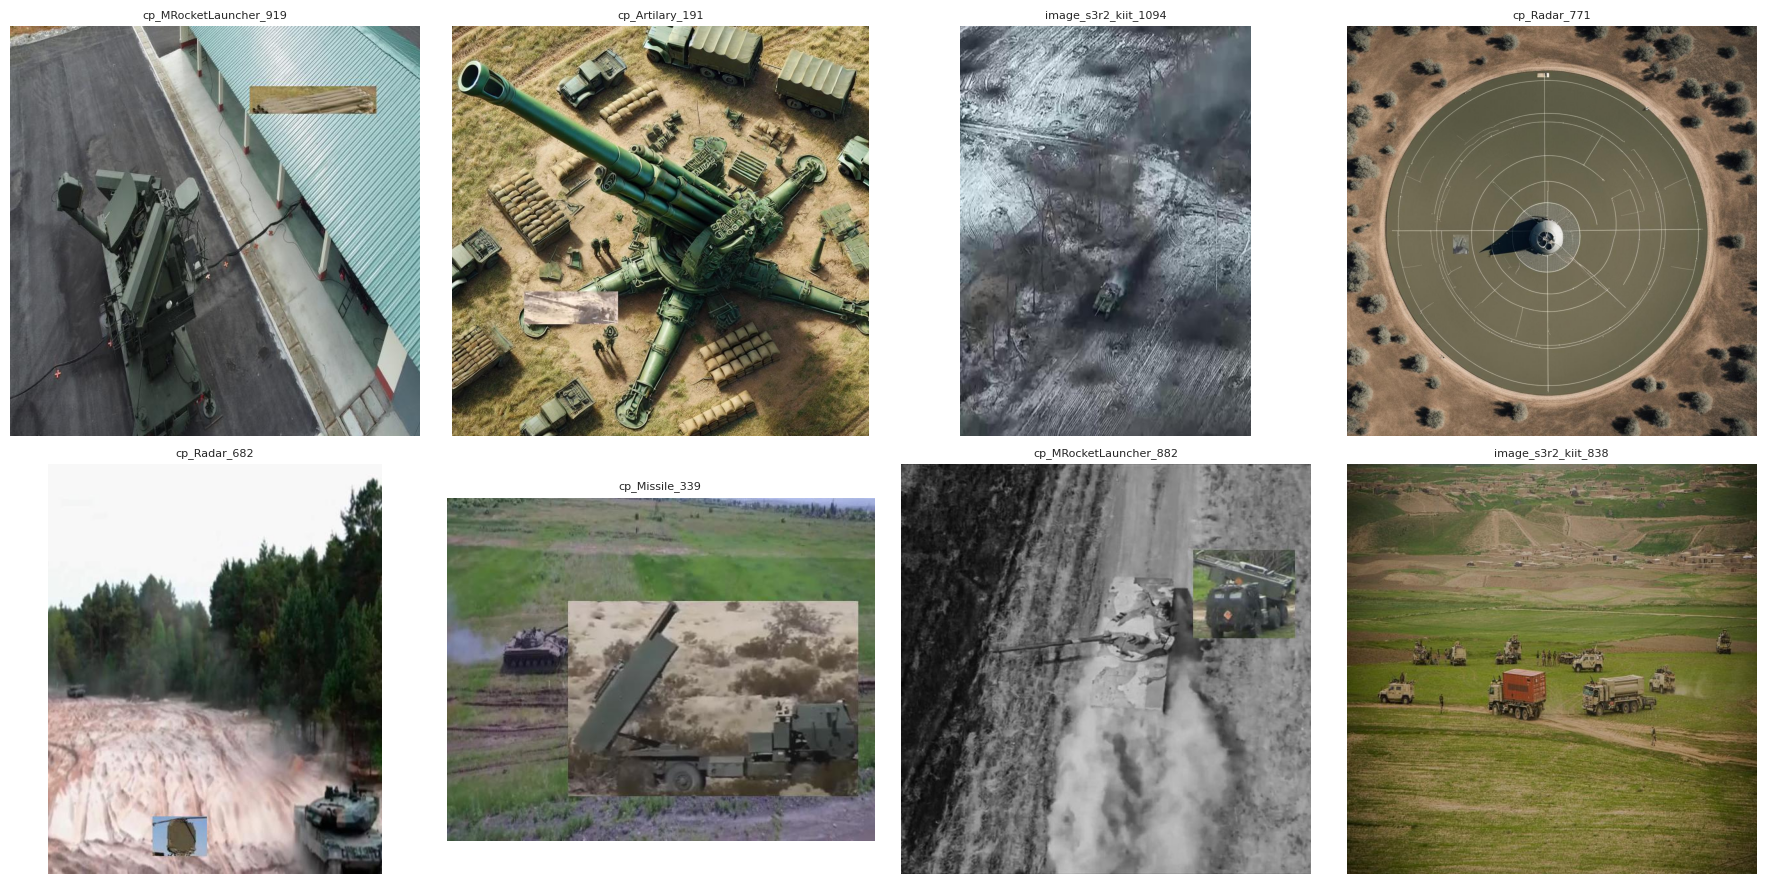

In [6]:
# Sample raw training images
sample_train_paths = random.Random(SEED).sample(train_images, min(8, len(train_images)))
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for ax, p in zip(axes.flat, sample_train_paths):
    ax.imshow(Image.open(p))
    ax.set_title(p.stem[:28], fontsize=8)
    ax.axis("off")
plt.tight_layout(); plt.show()

## 4. SimCLR config

Epoch budget and batch size are fixed across all four SSL methods and both baselines (fairness): here
that means `epochs=200`, `batch_size=32` per GPU (`64` total), `seed` (from the prep manifest).
`image_size=224` for SSL pretraining, different from the 640 used at detection fine-tuning time.
`temperature=0.20`, `learning_rate=3e-4` match the original reference config; `projection_dim=256`/
`hidden_dim=1024` follow `ssldet`'s updated defaults.

In [7]:
METHOD = "simclr"
PRETRAIN_OUTPUT_DIR = f"/kaggle/working/{METHOD}_kiitmita"

config = PretrainConfig(
    method=METHOD,
    image_roots=[str(SSL_POOL_TRAIN_DIR)],
    output_dir=PRETRAIN_OUTPUT_DIR,
    yolo_model="yolo26n.yaml",
    epochs=200,
    batch_size=32,
    image_size=224,
    workers=2,
    seed=SEED,
    learning_rate=3e-4,
    min_learning_rate=3e-6,
    weight_decay=1e-4,
    warmup_epochs=10,
    grad_accum_steps=1,
    gradient_clip=5.0,
    amp=True,
    projection_dim=256,
    hidden_dim=1024,
    temperature=0.20,
    save_every=5,
).validate()

pd.Series({
    "model": config.yolo_model, "epochs": config.epochs, "SSL pool images": len(train_images),
    "image size": config.image_size, "batch per GPU": config.batch_size,
    "source images per DDP step": config.batch_size * GPU_COUNT,
    "augmented views per DDP step": 2 * config.batch_size * GPU_COUNT,
    "temperature": config.temperature, "AMP": config.amp,
})

model                           yolo26n.yaml
epochs                                   200
SSL pool images                         2377
image size                               224
batch per GPU                             32
source images per DDP step                64
augmented views per DDP step             128
temperature                              0.2
AMP                                     True
dtype: object

## 5. Preview the augmented SimCLR views before training

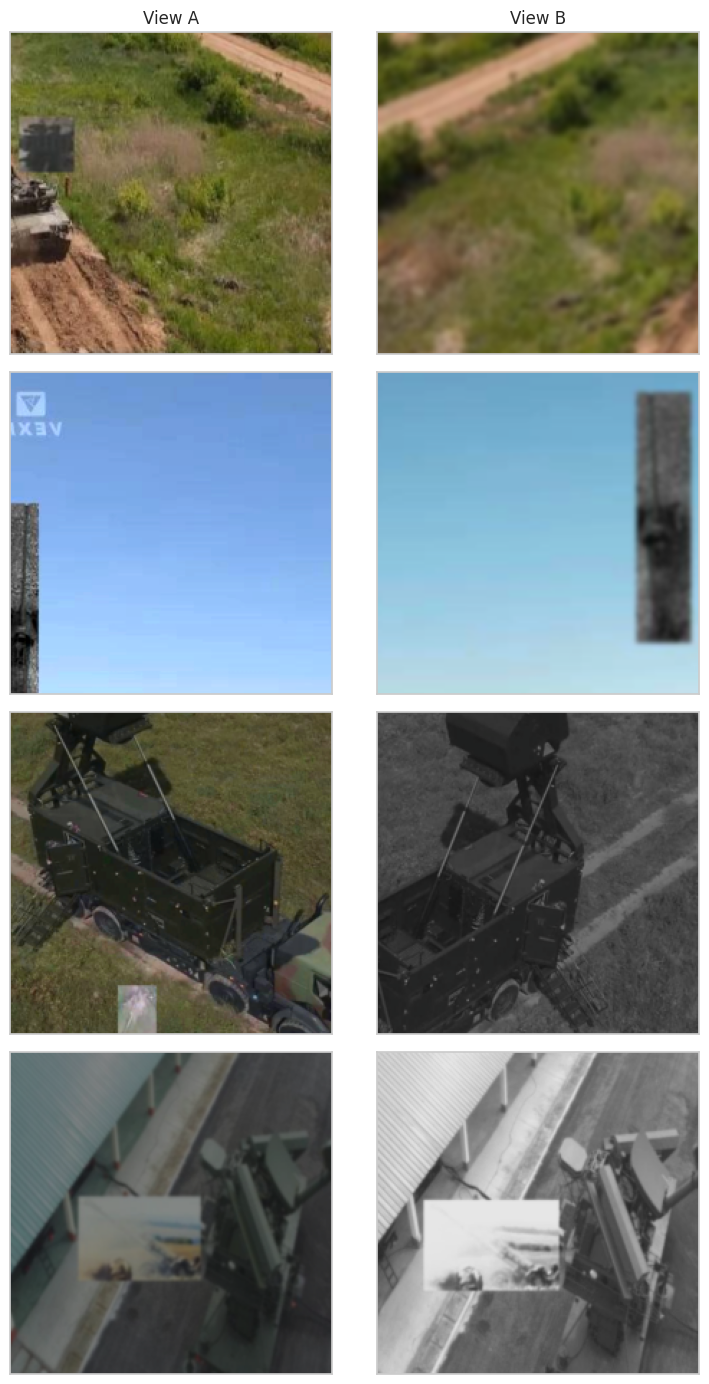

In [8]:
preview_dataset = UnlabeledImageDataset(train_images, build_transform(config))
mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
std = torch.tensor(IMAGENET_STD).view(3, 1, 1)

def display_tensor(tensor):
    return (tensor.cpu() * std + mean).clamp(0, 1).permute(1, 2, 0)

fig, axes = plt.subplots(4, 2, figsize=(8, 14))
for row in range(4):
    view_a, view_b = preview_dataset[row]
    axes[row, 0].imshow(display_tensor(view_a))
    axes[row, 1].imshow(display_tensor(view_b))
    for ax in axes[row]:
        ax.set_xticks([]); ax.set_yticks([])
axes[0, 0].set_title("View A"); axes[0, 1].set_title("View B")
plt.tight_layout(); plt.show()

## 6. Launch SimCLR pretraining (200 epochs, distributed across both T4s)

In [9]:
training_result = launch_distributed_pretrain(
    config, num_processes=GPU_COUNT,
    config_path=f"{PRETRAIN_OUTPUT_DIR}/simclr_config.yaml", check=True,
)
pd.Series({"completed": training_result.succeeded, "seconds": round(training_result.seconds, 1),
           "output directory": str(training_result.output_dir)})

SIMCLR 01/200:   0%|          | 0/37 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/ssldet/trainer.py:230: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()
/usr/local/lib/python3.12/dist-packages/ssldet/trainer.py:230: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()
SIM

Epoch 01 | loss=4.27238 | time=48.0s


SIMCLR 03/200:   0%|          | 0/37 [00:00<?, ?it/s]

Epoch 02 | loss=3.88552 | time=24.6s


SIMCLR 04/200:   0%|          | 0/37 [00:00<?, ?it/s]

...

SIMCLR 200/200:   0%|          | 0/37 [00:00<?, ?it/s]

Epoch 199 | loss=0.66321 | time=25.8s


SIMCLR 200/200: 100%|██████████| 37/37 [00:25<00:00,  1.43it/s, ema=1.00000, loss=0.6527, lr=3.00e-06]
/usr/local/lib/python3.12/dist-packages/torch/distributed/c10d_logger.py:83: UserWarning: barrier(): using the device under current context. You can specify `device_id` in `init_process_group` to mute this warning.
  return func(*args, **kwargs)


Epoch 200 | loss=0.66327 | time=25.9s
{
  "output_dir": "/kaggle/working/simclr_kiitmita",
  "yolo_checkpoint": "/kaggle/working/simclr_kiitmita/simclr_pretrained_yolo26n.pt",
  "ssl_checkpoint": "/kaggle/working/simclr_kiitmita/last_ssl.pt",
  "history_csv": "/kaggle/working/simclr_kiitmita/history.csv",
  "manifest_json": "/kaggle/working/simclr_kiitmita/run_manifest.json"
}
{
  "output_dir": "/kaggle/working/simclr_kiitmita",
  "yolo_checkpoint": "/kaggle/working/simclr_kiitmita/simclr_pretrained_yolo26n.pt",
  "ssl_checkpoint": "/kaggle/working/simclr_kiitmita/last_ssl.pt",
  "history_csv": "/kaggle/working/simclr_kiitmita/history.csv",
  "manifest_json": "/kaggle/working/simclr_kiitmita/run_manifest.json"
}


completed                                      True
seconds                                      5312.0
output directory    /kaggle/working/simclr_kiitmita
dtype: object

## 7. Loss curve

,epoch,loss,learning_rate,ema_momentum,seconds
0,1,4.272377,0.000031,0.996000,47.995126
1,2,3.885525,0.000061,0.996001,24.586473
2,3,3.500320,0.000091,0.996002,24.786469
3,4,3.138793,0.000121,0.996004,25.309778
4,5,2.708974,0.000151,0.996006,24.003447
...,...,...,...,...,...
195,196,0.674852,0.000003,0.999996,25.570385
196,197,0.656026,0.000003,0.999998,25.913010
197,198,0.682499,0.000003,0.999999,28.348590
198,199,0.663214,0.000003,1.000000,25.802154


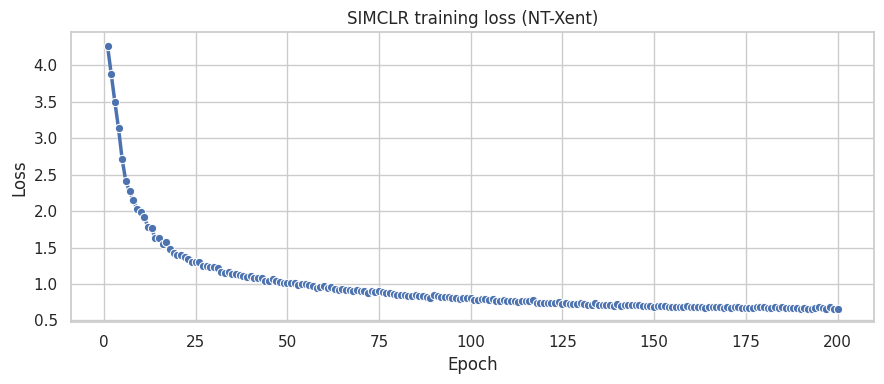

In [10]:
history = pd.read_csv(f"{PRETRAIN_OUTPUT_DIR}/history.csv")
display(history.round(6))

fig, ax = plt.subplots(figsize=(9, 4))
sns.lineplot(data=history, x="epoch", y="loss", marker="o", linewidth=2.5, ax=ax)
ax.set_title(f"{METHOD.upper()} training loss (NT-Xent)"); ax.set_ylabel("Loss"); ax.set_xlabel("Epoch")
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.tight_layout(); plt.show()

## 8. Locate the exported checkpoints

In [11]:
manifest = json.loads((Path(PRETRAIN_OUTPUT_DIR) / "run_manifest.json").read_text())
YOLO_CHECKPOINT = Path(manifest["outputs"]["yolo_checkpoint"])
SSL_CHECKPOINT = Path(manifest["outputs"]["ssl_checkpoint"])

pd.Series({
    "initialization": manifest["initialization"], "unlabeled images": manifest["unlabeled_images"],
    "world size": manifest["world_size"], "best loss": manifest["best_loss"],
    "YOLO checkpoint": str(YOLO_CHECKPOINT), "full SimCLR checkpoint": str(SSL_CHECKPOINT),
})

initialization            random initialization; strict label-free SSL p...
unlabeled images                                                       2377
world size                                                                2
best loss                                                          0.656026
YOLO checkpoint           /kaggle/working/simclr_kiitmita/simclr_pretrai...
full SimCLR checkpoint          /kaggle/working/simclr_kiitmita/last_ssl.pt
dtype: object

## 9. Extract validation features

Embed every validation image with the trained backbone. Validation images are always 100% raw (never
copy-paste-augmented), so this is a clean generalisation check.


In [12]:
import torchvision.transforms.v2 as v2

detector = YOLO(str(YOLO_CHECKPOINT))
encoder = YOLOBackboneEncoder(detector.model).to(DEVICE).eval()
infer_tf = v2.Compose([v2.Resize((config.image_size, config.image_size)), v2.ToImage(),
                        v2.ToDtype(torch.float32, scale=True), v2.Normalize(IMAGENET_MEAN, IMAGENET_STD)])

EMBEDDING_LIMIT = 200
selected_paths = val_images if len(val_images) <= EMBEDDING_LIMIT else random.Random(SEED).sample(val_images, EMBEDDING_LIMIT)

feats, paths = [], []
with torch.inference_mode():
    for p in tqdm(selected_paths, desc="Embedding val images"):
        x = infer_tf(Image.open(p).convert("RGB")).unsqueeze(0).to(DEVICE)
        feat = torch.nn.functional.normalize(encoder(x).flatten(1), dim=1)
        feats.append(feat.squeeze(0).cpu().numpy())
        paths.append(p)

feature_matrix = np.stack(feats)
pd.Series({
    "images": float(len(feature_matrix)),
    "feature dimensions": float(feature_matrix.shape[1]),
    "feature norm mean": float(np.linalg.norm(feature_matrix, axis=1).mean()),
})

Embedding val images:   0%|          | 0/164 [00:00<?, ?it/s]

images                164.0
feature dimensions    256.0
feature norm mean       1.0
dtype: float64

## 10. t-SNE of validation embeddings, coloured by dominant class

Val labels exist on disk (only the SSL-pool/train labels are unused for pretraining) — colour by each
image's dominant class using them, so this plot actually shows colour variation.


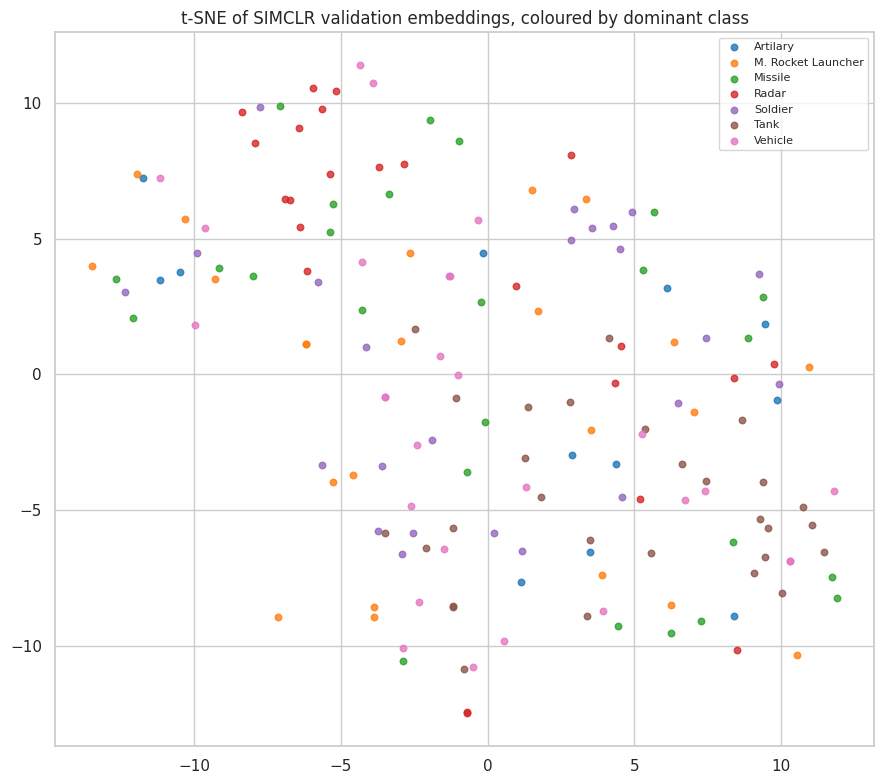

In [13]:
def dominant_class_for_stem(stem, labels_dir):
    lbl_path = Path(labels_dir) / f"{stem}.txt"
    counts = Counter()
    if lbl_path.exists():
        with open(lbl_path) as f:
            for line in f:
                parts = line.strip().split()
                if parts:
                    counts[int(float(parts[0]))] += 1
    return CLASS_NAMES[counts.most_common(1)[0][0]] if counts else "No Label"

val_labels_dir = RESPLIT_ROOT / "val" / "labels"
point_classes = [dominant_class_for_stem(p.stem, val_labels_dir) for p in paths]

perplexity = min(30.0, max(2.0, (len(feature_matrix) - 1) / 3))
tsne_xy = TSNE(n_components=2, random_state=SEED, perplexity=perplexity).fit_transform(feature_matrix)

fig, ax = plt.subplots(figsize=(9, 8))
palette = sns.color_palette("tab10", n_colors=len(set(point_classes)))
for color, cls in zip(palette, sorted(set(point_classes))):
    idx = [i for i, c in enumerate(point_classes) if c == cls]
    ax.scatter(tsne_xy[idx, 0], tsne_xy[idx, 1], label=cls, s=22, alpha=0.8, color=color)
ax.legend(fontsize=8, loc="best"); ax.set_title(f"t-SNE of {METHOD.upper()} validation embeddings, coloured by dominant class")
plt.tight_layout(); plt.show()

## 11. Nearest-neighbour retrieval

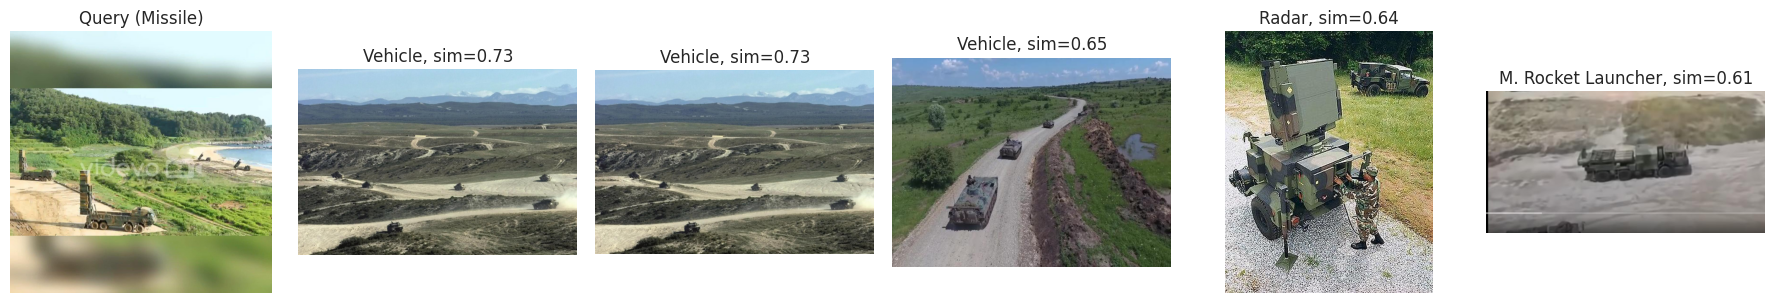

In [14]:
sims = cosine_similarity(feature_matrix)
QUERY_INDEX = 0
NEIGHBOR_COUNT = min(5, len(feature_matrix) - 1)
neighbour_idx = np.argsort(-sims[QUERY_INDEX])[1:NEIGHBOR_COUNT + 1]

fig, axes = plt.subplots(1, NEIGHBOR_COUNT + 1, figsize=(3 * (NEIGHBOR_COUNT + 1), 3.2))
axes[0].imshow(Image.open(paths[QUERY_INDEX]))
axes[0].set_title(f"Query ({point_classes[QUERY_INDEX]})"); axes[0].axis("off")
for ax, idx in zip(axes[1:], neighbour_idx):
    ax.imshow(Image.open(paths[idx])); ax.set_title(f"{point_classes[idx]}, sim={sims[QUERY_INDEX, idx]:.2f}"); ax.axis("off")
plt.tight_layout(); plt.show()

## 12. Shortcut-learning check — raw vs. copy-paste synthetic, on the TRAIN pool

This check needs images that actually include copy-paste synthetics, so it runs on the **train** pool
specifically (not validation, which is always 100% raw and would show only one colour here).


Embedding train-pool images:   0%|          | 0/300 [00:00<?, ?it/s]

Raw: 155 | Copy-paste synthetic: 145


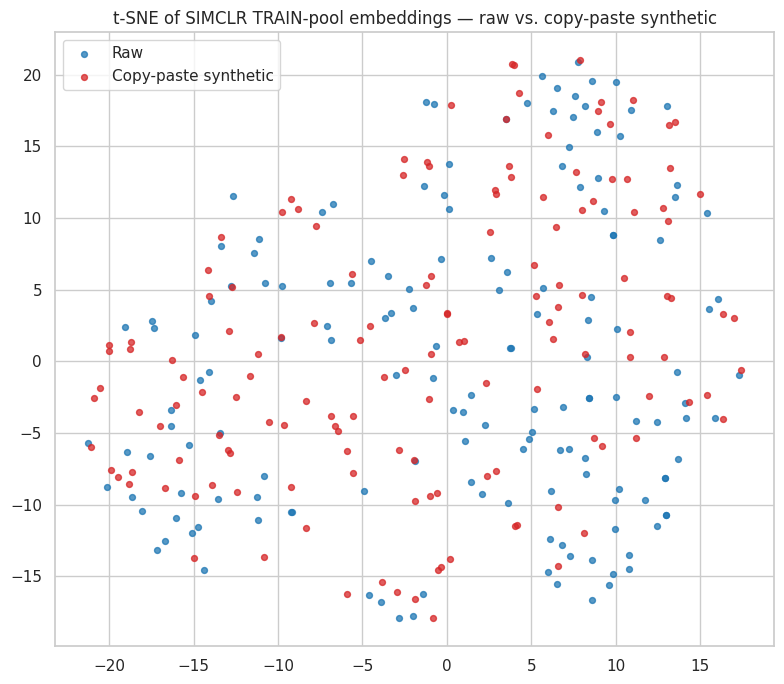

In [15]:
TRAIN_DIAGNOSTIC_LIMIT = 300
train_stem_set_raw = set(stems_train)
train_sample_paths = train_images if len(train_images) <= TRAIN_DIAGNOSTIC_LIMIT else random.Random(SEED).sample(train_images, TRAIN_DIAGNOSTIC_LIMIT)

train_feats, train_is_synthetic = [], []
with torch.inference_mode():
    for p in tqdm(train_sample_paths, desc="Embedding train-pool images"):
        x = infer_tf(Image.open(p).convert("RGB")).unsqueeze(0).to(DEVICE)
        feat = torch.nn.functional.normalize(encoder(x).flatten(1), dim=1)
        train_feats.append(feat.squeeze(0).cpu().numpy())
        train_is_synthetic.append(p.stem not in train_stem_set_raw)  # cp_*/cp20_* stems are synthetic

train_feature_matrix = np.stack(train_feats)
print("Raw:", train_is_synthetic.count(False), "| Copy-paste synthetic:", train_is_synthetic.count(True))

perplexity_train = min(30.0, max(2.0, (len(train_feature_matrix) - 1) / 3))
tsne_train_xy = TSNE(n_components=2, random_state=SEED, perplexity=perplexity_train).fit_transform(train_feature_matrix)

fig, ax = plt.subplots(figsize=(8, 7))
for flag, label, color in [(False, "Raw", "tab:blue"), (True, "Copy-paste synthetic", "tab:red")]:
    idx = [i for i, s in enumerate(train_is_synthetic) if s == flag]
    ax.scatter(tsne_train_xy[idx, 0], tsne_train_xy[idx, 1], label=label, s=18, alpha=0.75, c=color)
ax.legend(); ax.set_title(f"t-SNE of {METHOD.upper()} TRAIN-pool embeddings — raw vs. copy-paste synthetic")
plt.tight_layout(); plt.show()

## 13. Quantitative collapse diagnostics — beyond eyeballing one query

Two rigorous, standard SSL diagnostics, computed over the validation embedding batch:

- **Pairwise similarity distribution**: histogram of every off-diagonal cosine similarity. A collapsed
  encoder produces a sharp spike near 1.0 regardless of image content; a healthy encoder produces a much
  wider spread.
- **Effective rank (singular-value spectrum)**: SVD of the embedding matrix. A collapsed encoder's
  embeddings live in a near-1-dimensional subspace; a healthy encoder uses many more directions.


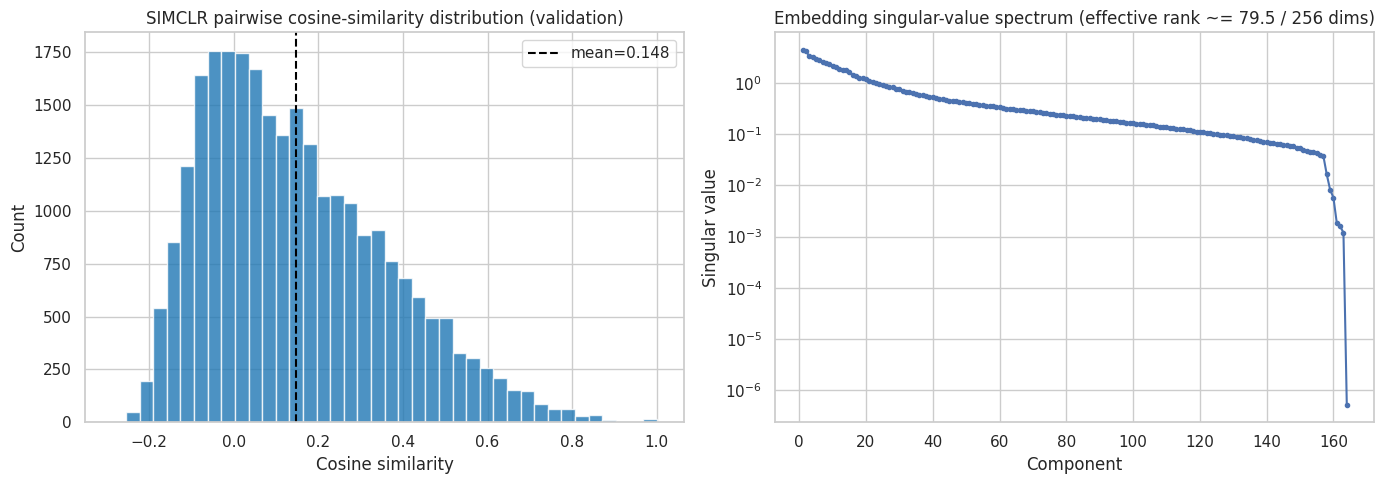

mean pairwise similarity                                       0.1476
std pairwise similarity                                        0.2148
effective rank                                                  79.54
embedding dimensionality                                          256
collapse read               no strong collapse signature by this test
dtype: object

In [16]:
pairwise_sims = cosine_similarity(feature_matrix)
off_diagonal = pairwise_sims[~np.eye(len(pairwise_sims), dtype=bool)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(off_diagonal, bins=40, color="tab:blue", alpha=0.8)
axes[0].axvline(off_diagonal.mean(), color="black", linestyle="--", label=f"mean={off_diagonal.mean():.3f}")
axes[0].set_title(f"{METHOD.upper()} pairwise cosine-similarity distribution (validation)")
axes[0].set_xlabel("Cosine similarity"); axes[0].set_ylabel("Count"); axes[0].legend()

singular_values = np.linalg.svd(feature_matrix - feature_matrix.mean(axis=0), compute_uv=False)
normalized_sv = singular_values / singular_values.sum()
effective_rank = float(np.exp(-(normalized_sv * np.log(normalized_sv + 1e-12)).sum()))
axes[1].plot(range(1, len(singular_values) + 1), singular_values, marker="o", markersize=3)
axes[1].set_title(f"Embedding singular-value spectrum (effective rank ~= {effective_rank:.1f} / {feature_matrix.shape[1]} dims)")
axes[1].set_xlabel("Component"); axes[1].set_ylabel("Singular value"); axes[1].set_yscale("log")
plt.tight_layout(); plt.show()

pd.Series({
    "mean pairwise similarity": round(float(off_diagonal.mean()), 4),
    "std pairwise similarity": round(float(off_diagonal.std()), 4),
    "effective rank": round(effective_rank, 2),
    "embedding dimensionality": feature_matrix.shape[1],
    "collapse read": ("LIKELY COLLAPSED - similarities tightly clustered near 1.0 and/or effective rank very low"
                       if off_diagonal.mean() > 0.9 and off_diagonal.std() < 0.05
                       else "no strong collapse signature by this test"),
})

## 14. Exercise — temperature ablation ($\tau=0.10$)

Train a shorter experiment with temperature $\tau=0.10$ (main run above used $\tau=0.20$, 200 epochs).
Compare its loss curve, t-SNE neighbourhoods, and nearest neighbours with the original run. The random
seed and the selected validation images (`selected_paths`) are kept unchanged from the main run so the
comparison is fair — only temperature and epoch count differ.

**Prediction before running:** SimCLR's NT-Xent loss divides similarity scores by $\tau$ before the
softmax (`logit = similarity / tau`). A smaller $\tau$ amplifies the gap between the closest negative and
the rest, making the softmax **sharper** — the loss concentrates more on the single hardest negative
rather than spreading gradient across many negatives roughly equally. $\tau=0.10$ should therefore behave
more sharply than the main run's $\tau=0.20$.

**Honest caveat:** this exercise run uses 50 epochs, far fewer than the main run's 200 — so any
difference observed below is a mix of the temperature effect and the shorter training, not temperature
alone. This is a real confound and is called out explicitly in the reflection below rather than resolved,
since isolating it cleanly would need an additional epoch-matched control run beyond what was asked here.


In [17]:
from dataclasses import replace

exercise_config = replace(
    config,
    temperature=0.10,
    epochs=50,
    warmup_epochs=3,
    output_dir=f"/kaggle/working/{METHOD}_kiitmita_temp010",
).validate()

pd.Series({
    "temperature": exercise_config.temperature,
    "epochs": exercise_config.epochs,
    "warmup_epochs": exercise_config.warmup_epochs,
    "output directory": exercise_config.output_dir,
})

temperature                                             0.1
epochs                                                   50
warmup_epochs                                             3
output directory    /kaggle/working/simclr_kiitmita_temp010
dtype: object

In [18]:
exercise_result = launch_distributed_pretrain(
    exercise_config, num_processes=GPU_COUNT,
    config_path=f"{exercise_config.output_dir}/simclr_temp010_config.yaml", check=True,
)

SIMCLR 01/50:   0%|          | 0/37 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/ssldet/trainer.py:230: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()
SIMCLR 01/50:   0%|          | 0/37 [00:24<?, ?it/s, ema=0.99600, loss=5.7284, lr=5.41e-06]/usr/local/lib/python3.12/dist-packages/ssldet/trainer.py:230: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at htt

Epoch 01 | loss=4.53485 | time=47.0s


SIMCLR 03/50:   0%|          | 0/37 [00:00<?, ?it/s]

Epoch 02 | loss=3.51192 | time=25.0s


SIMCLR 04/50:   0%|          | 0/37 [00:00<?, ?it/s]

...

Epoch 48 | loss=0.37599 | time=25.7s


SIMCLR 50/50:   0%|          | 0/37 [00:00<?, ?it/s]

Epoch 49 | loss=0.37930 | time=26.0s


SIMCLR 50/50: 100%|██████████| 37/37 [00:25<00:00,  1.45it/s, ema=1.00000, loss=0.3773, lr=3.00e-06]
/usr/local/lib/python3.12/dist-packages/torch/distributed/c10d_logger.py:83: UserWarning: barrier(): using the device under current context. You can specify `device_id` in `init_process_group` to mute this warning.
  return func(*args, **kwargs)


Epoch 50 | loss=0.36623 | time=25.6s
{
  "output_dir": "/kaggle/working/simclr_kiitmita_temp010",
  "yolo_checkpoint": "/kaggle/working/simclr_kiitmita_temp010/simclr_pretrained_yolo26n.pt",
  "ssl_checkpoint": "/kaggle/working/simclr_kiitmita_temp010/last_ssl.pt",
  "history_csv": "/kaggle/working/simclr_kiitmita_temp010/history.csv",
  "manifest_json": "/kaggle/working/simclr_kiitmita_temp010/run_manifest.json"
}
{
  "output_dir": "/kaggle/working/simclr_kiitmita_temp010",
  "yolo_checkpoint": "/kaggle/working/simclr_kiitmita_temp010/simclr_pretrained_yolo26n.pt",
  "ssl_checkpoint": "/kaggle/working/simclr_kiitmita_temp010/last_ssl.pt",
  "history_csv": "/kaggle/working/simclr_kiitmita_temp010/history.csv",
  "manifest_json": "/kaggle/working/simclr_kiitmita_temp010/run_manifest.json"
}


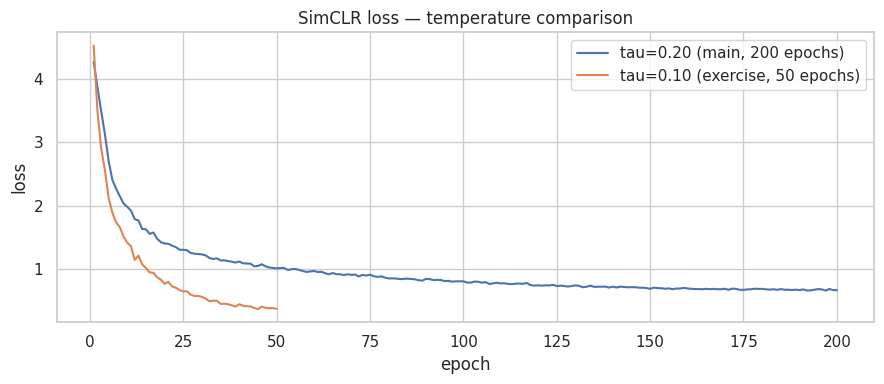

In [19]:
exercise_history = pd.read_csv(f"{exercise_config.output_dir}/history.csv")

fig, ax = plt.subplots(figsize=(9, 4))
sns.lineplot(data=history, x="epoch", y="loss", label="tau=0.20 (main, 200 epochs)", ax=ax)
sns.lineplot(data=exercise_history, x="epoch", y="loss", label="tau=0.10 (exercise, 50 epochs)", ax=ax)
ax.set_title("SimCLR loss — temperature comparison")
plt.tight_layout(); plt.show()

Feature extraction on the *same* validation images as the main run, for a fair comparison.

In [20]:
exercise_manifest = json.loads((Path(exercise_config.output_dir) / "run_manifest.json").read_text())
EXERCISE_YOLO_CHECKPOINT = Path(exercise_manifest["outputs"]["yolo_checkpoint"])

exercise_detector = YOLO(str(EXERCISE_YOLO_CHECKPOINT))
exercise_encoder = YOLOBackboneEncoder(exercise_detector.model).to(DEVICE).eval()

exercise_feats = []
with torch.inference_mode():
    for p in tqdm(selected_paths, desc="Embedding val images (tau=0.10)"):
        x = infer_tf(Image.open(p).convert("RGB")).unsqueeze(0).to(DEVICE)
        feat = torch.nn.functional.normalize(exercise_encoder(x).flatten(1), dim=1)
        exercise_feats.append(feat.squeeze(0).cpu().numpy())
exercise_feature_matrix = np.stack(exercise_feats)

Embedding val images (tau=0.10):   0%|          | 0/164 [00:00<?, ?it/s]

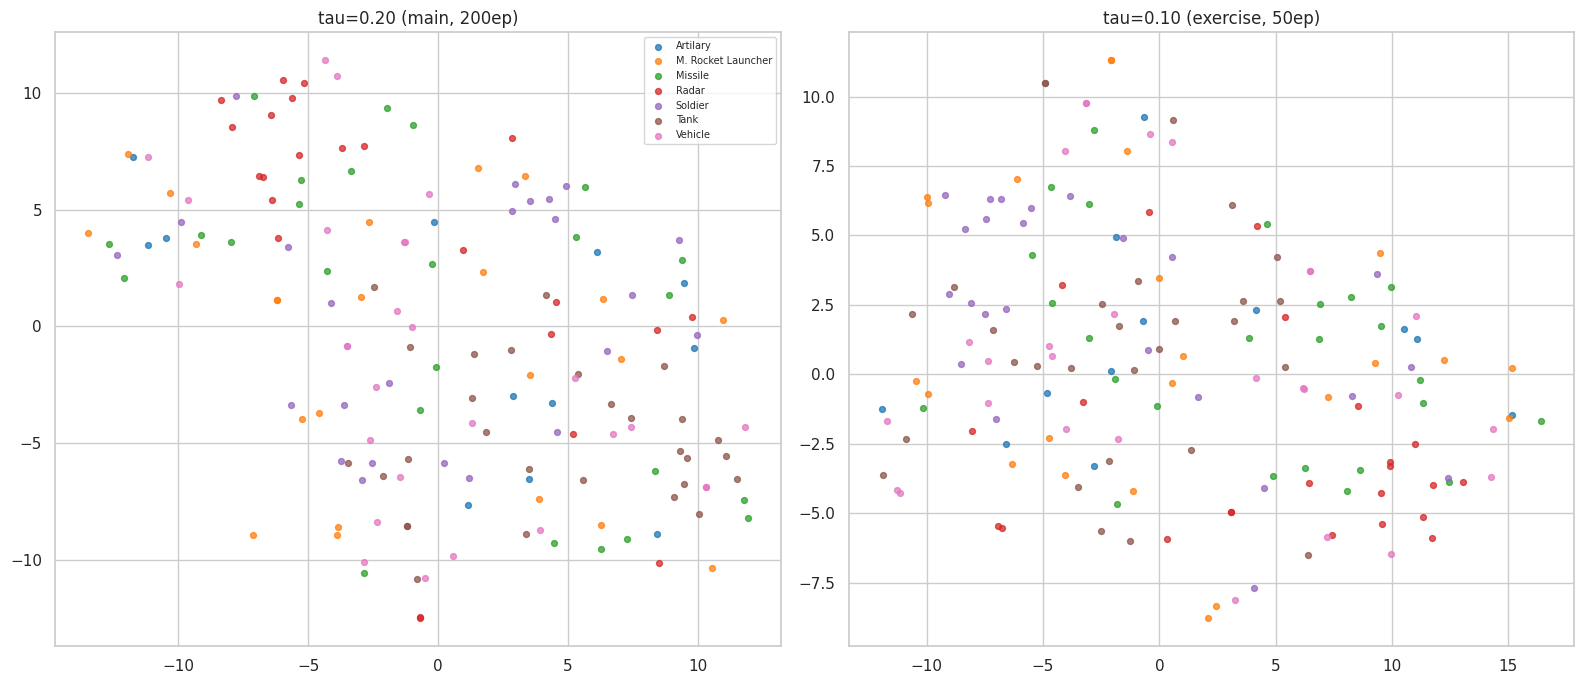

In [21]:
tsne_main = TSNE(n_components=2, random_state=SEED, perplexity=perplexity).fit_transform(feature_matrix)
tsne_exercise = TSNE(n_components=2, random_state=SEED, perplexity=perplexity).fit_transform(exercise_feature_matrix)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, xy, title in [(axes[0], tsne_main, "tau=0.20 (main, 200ep)"), (axes[1], tsne_exercise, "tau=0.10 (exercise, 50ep)")]:
    for color, cls in zip(palette, sorted(set(point_classes))):
        idx = [i for i, c in enumerate(point_classes) if c == cls]
        ax.scatter(xy[idx, 0], xy[idx, 1], label=cls, s=18, alpha=0.75, color=color)
    ax.set_title(title)
axes[0].legend(fontsize=7)
plt.tight_layout(); plt.show()

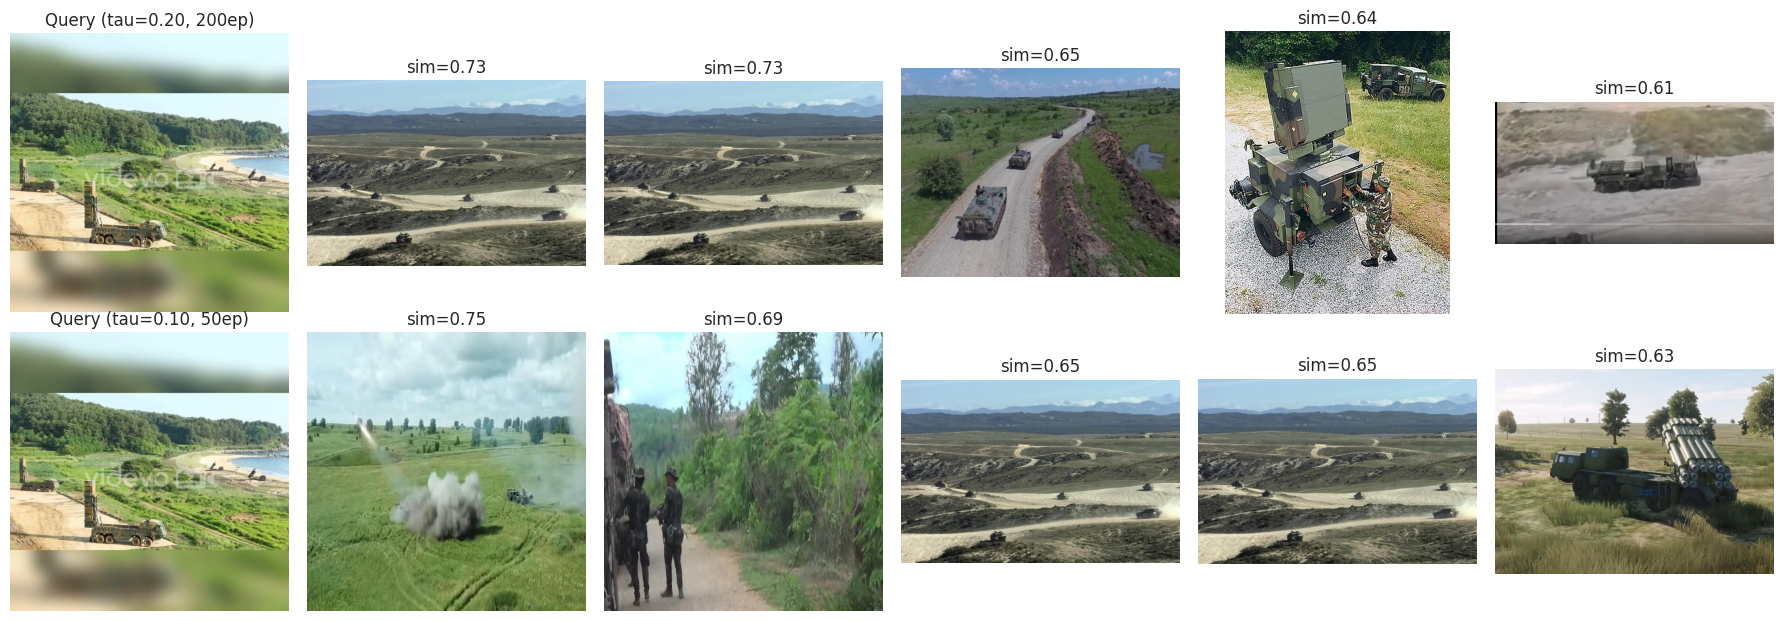

In [22]:
sims_main = cosine_similarity(feature_matrix)
sims_exercise = cosine_similarity(exercise_feature_matrix)

fig, axes = plt.subplots(2, NEIGHBOR_COUNT + 1, figsize=(3 * (NEIGHBOR_COUNT + 1), 6.4))
for row, (sims, title) in enumerate([(sims_main, "tau=0.20, 200ep"), (sims_exercise, "tau=0.10, 50ep")]):
    neighbour_idx = np.argsort(-sims[QUERY_INDEX])[1:NEIGHBOR_COUNT + 1]
    axes[row, 0].imshow(Image.open(paths[QUERY_INDEX])); axes[row, 0].set_title(f"Query ({title})"); axes[row, 0].axis("off")
    for col, idx in enumerate(neighbour_idx, start=1):
        axes[row, col].imshow(Image.open(paths[idx])); axes[row, col].set_title(f"sim={sims[QUERY_INDEX, idx]:.2f}"); axes[row, col].axis("off")
plt.tight_layout(); plt.show()

Numeric answer to the sharper-vs-smoother prediction, using the same collapse-diagnostic test as the main run.

In [23]:
def collapse_stats(fm):
    sims = cosine_similarity(fm)
    off = sims[~np.eye(len(sims), dtype=bool)]
    sv = np.linalg.svd(fm - fm.mean(axis=0), compute_uv=False)
    p = sv / sv.sum()
    eff_rank = float(np.exp(-(p * np.log(p + 1e-12)).sum()))
    return off.mean(), off.std(), eff_rank

mean20, std20, rank20 = collapse_stats(feature_matrix)
mean10, std10, rank10 = collapse_stats(exercise_feature_matrix)

pd.DataFrame({
    "tau=0.20 (main, 200ep)": [mean20, std20, rank20],
    "tau=0.10 (exercise, 50ep)": [mean10, std10, rank10],
}, index=["mean pairwise similarity", "std pairwise similarity", "effective rank"]).round(4)

,"tau=0.20 (main, 200ep)","tau=0.10 (exercise, 50ep)"
mean pairwise similarity,0.1476,0.2093
std pairwise similarity,0.2148,0.2318
effective rank,79.5360,71.1096


## 15. Publish the checkpoint for Notebook 1b

Run *Save & Run All (Commit)*, then attach this notebook's output as an input to `group02-partB-01b-simclr-detect`.

In [24]:
print("Attach this notebook as a Kaggle input to Notebook 1b.")
print("SSL checkpoint:", SSL_CHECKPOINT)
print("YOLO checkpoint:", YOLO_CHECKPOINT)

Attach this notebook as a Kaggle input to Notebook 1b.
SSL checkpoint: /kaggle/working/simclr_kiitmita/last_ssl.pt
YOLO checkpoint: /kaggle/working/simclr_kiitmita/simclr_pretrained_yolo26n.pt
